# Notebook 2 : Approches ML Classiques - Prédiction des Notes

Ce notebook compare différentes représentations textuelles avec des algorithmes de ML classiques pour la **prédiction des notes (1-5 étoiles)**.

**Représentations testées :**
- Bag of Words (BOW)
- TF-IDF
- Embeddings pré-entraînés (Sentence-BERT)

**Algorithmes testés :**
- Logistic Regression
- SVM
- Naive Bayes
- Random Forest

**Tâche :**
- Classification de rating (5 classes : 1-5 étoiles)

## 1. Imports et Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')

import pickle
import scipy.sparse

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from src.evaluation import evaluate_model, load_results

import json
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

FEATURES_DIR = '../data/precomputed'

## 2. Chargement et Preprocessing des Données

In [3]:
with open(f'{FEATURES_DIR}/train_test_split.pkl', 'rb') as f:
    splits = pickle.load(f)

X_train = splits['X_train']
X_test = splits['X_test']
y_train_pol = splits['y_train_pol']
y_test_pol = splits['y_test_pol']
y_train_rating = splits['y_train_rating']
y_test_rating = splits['y_test_rating']

print(f"Train set : {len(X_train)} reviews")
print(f"Test set  : {len(X_test)} reviews")

Train set : 798328 reviews
Test set  : 199583 reviews


In [4]:
# Vérification des distributions
print(f"Polarité (train) :")
print(y_train_pol.value_counts())
print(f"\nRating (train) :")
print(y_train_rating.value_counts())

Polarité (train) :
polarite
positive    535139
negative    184373
neutral      78816
Name: count, dtype: int64

Rating (train) :
rating
5    369277
4    165862
1    122333
3     78816
2     62040
Name: count, dtype: int64


## 3. Train/Test Split

In [5]:
print(f"Train set : {len(X_train)} reviews")
print(f"Test set  : {len(X_test)} reviews")
print(f"\nTrain rating distribution :")
print(y_train_rating.value_counts().sort_index())

Train set : 798328 reviews
Test set  : 199583 reviews

Train rating distribution :
rating
1    122333
2     62040
3     78816
4    165862
5    369277
Name: count, dtype: int64


## 5. Approche 1 : Bag of Words (BOW)

Représentation la plus simple : comptage des occurrences de mots.

In [6]:
# Chargement BOW précalculé
X_train_bow = scipy.sparse.load_npz(f'{FEATURES_DIR}/bow_train.npz')
X_test_bow = scipy.sparse.load_npz(f'{FEATURES_DIR}/bow_test.npz')
with open(f'{FEATURES_DIR}/bow_vectorizer.pkl', 'rb') as f:
    bow_vectorizer = pickle.load(f)

print(f"BOW shape: {X_train_bow.shape}")
print(f"Vocabulaire size: {len(bow_vectorizer.vocabulary_)}")
print(f"Sparsity: {(1.0 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1])):.2%}")

BOW shape: (798328, 5000)
Vocabulaire size: 5000
Sparsity: 99.28%


### 5.1 BOW + Logistic Regression


 BOW + LogReg
Accuracy:     0.6807
F1-macro:     0.5558
F1-weighted:  0.6557

              precision    recall  f1-score   support

           1       0.73      0.85      0.78     30583
           2       0.46      0.28      0.34     15510
           3       0.48      0.34      0.40     19704
           4       0.54      0.37      0.44     41466
           5       0.75      0.91      0.82     92320

    accuracy                           0.68    199583
   macro avg       0.59      0.55      0.56    199583
weighted avg       0.65      0.68      0.66    199583



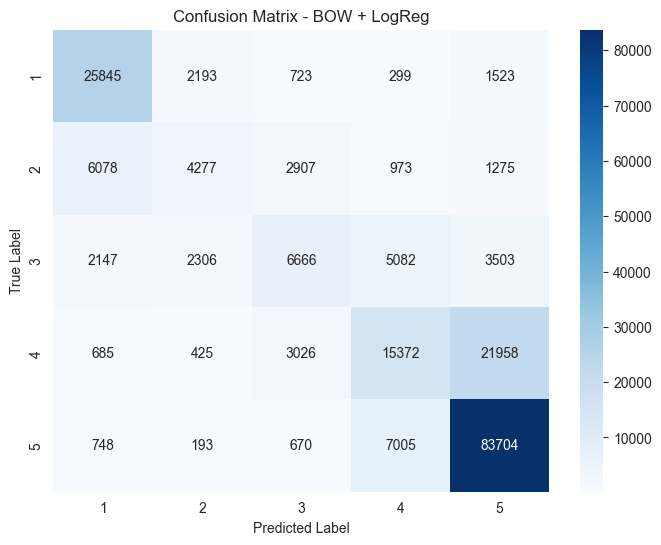

{'model': 'BOW + LogReg',
 'type': 'ML Classique',
 'accuracy': 0.6807393415270839,
 'f1_macro': 0.5557509819090629,
 'f1_weighted': 0.6556688728547786}

In [7]:
lr_bow = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE, 
    C=1.0,
)   

lr_bow.fit(X_train_bow, y_train_rating)
evaluate_model(lr_bow, X_test_bow, y_test_rating, "BOW + LogReg")

### 5.2 BOW + SVM


 BOW + SVM
Accuracy:     0.6675
F1-macro:     0.5096
F1-weighted:  0.6258

              precision    recall  f1-score   support

           1       0.71      0.86      0.78     30583
           2       0.46      0.17      0.25     15510
           3       0.50      0.23      0.31     19704
           4       0.51      0.33      0.40     41466
           5       0.71      0.93      0.81     92320

    accuracy                           0.67    199583
   macro avg       0.58      0.50      0.51    199583
weighted avg       0.63      0.67      0.63    199583



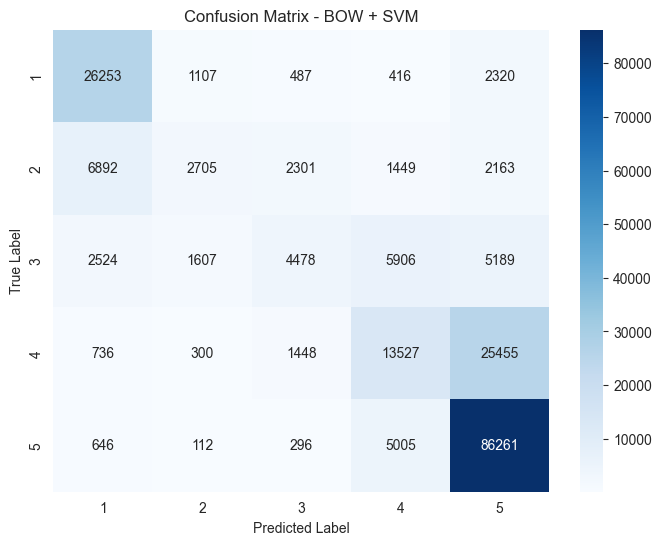

{'model': 'BOW + SVM',
 'type': 'ML Classique',
 'accuracy': 0.6675117620238197,
 'f1_macro': 0.5096439868524161,
 'f1_weighted': 0.6258125552282903}

In [8]:
svm_bow = LinearSVC(
    max_iter=2000, 
    random_state=RANDOM_STATE
)

svm_bow.fit(X_train_bow, y_train_rating)
evaluate_model(svm_bow, X_test_bow, y_test_rating, "BOW + SVM")

### 5.3 BOW + Naive Bayes


 BOW + NaiveBayes
Accuracy:     0.6080
F1-macro:     0.5189
F1-weighted:  0.6137

              precision    recall  f1-score   support

           1       0.62      0.70      0.66     30583
           2       0.31      0.31      0.31     15510
           3       0.38      0.37      0.38     19704
           4       0.45      0.54      0.49     41466
           5       0.81      0.71      0.76     92320

    accuracy                           0.61    199583
   macro avg       0.52      0.53      0.52    199583
weighted avg       0.62      0.61      0.61    199583



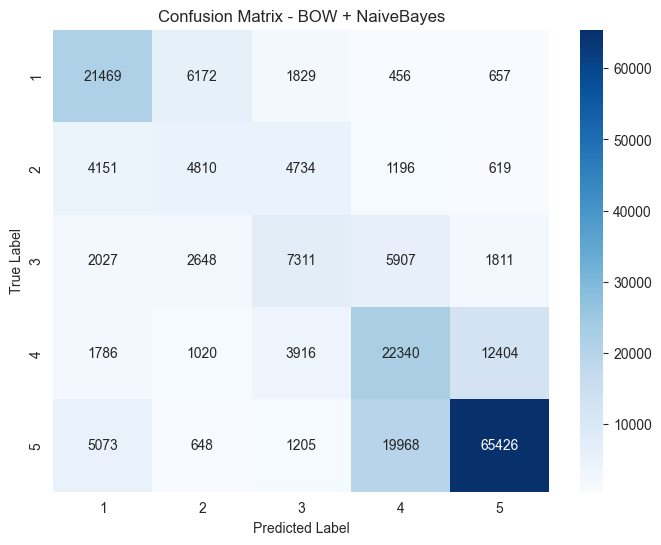

{'model': 'BOW + NaiveBayes',
 'type': 'ML Classique',
 'accuracy': 0.6080477796205087,
 'f1_macro': 0.5188622358228937,
 'f1_weighted': 0.6136832389871008}

In [9]:
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train_rating)
evaluate_model(nb_bow, X_test_bow, y_test_rating, "BOW + NaiveBayes")

### 5.4 BOW + Random Forest


 BOW + RandomForest
Accuracy:     0.5408
F1-macro:     0.2664
F1-weighted:  0.4168

              precision    recall  f1-score   support

           1       0.74      0.50      0.59     30583
           2       0.69      0.00      0.00     15510
           3       0.46      0.01      0.01     19704
           4       0.38      0.02      0.04     41466
           5       0.52      0.99      0.68     92320

    accuracy                           0.54    199583
   macro avg       0.56      0.30      0.27    199583
weighted avg       0.53      0.54      0.42    199583



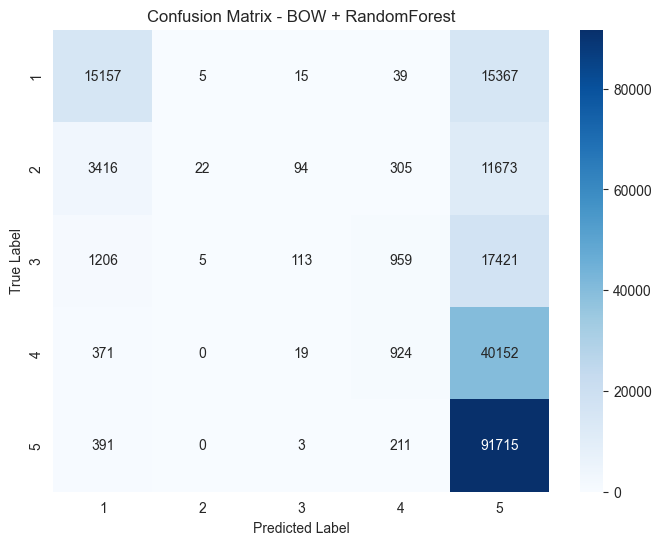

{'model': 'BOW + RandomForest',
 'type': 'ML Classique',
 'accuracy': 0.5407825315783409,
 'f1_macro': 0.26639843602025276,
 'f1_weighted': 0.416778205272907}

In [10]:
rf_bow = RandomForestClassifier(
    n_estimators=100, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    max_depth=20
)
rf_bow.fit(X_train_bow, y_train_rating)
evaluate_model(rf_bow, X_test_bow, y_test_rating, "BOW + RandomForest")

## 6. Approche 2 : TF-IDF

Pondération des mots par leur importance (terme fréquence × inverse document fréquence).

In [11]:
# Chargement TF-IDF précalculé
X_train_tfidf = scipy.sparse.load_npz(f'{FEATURES_DIR}/tfidf_train.npz')
X_test_tfidf = scipy.sparse.load_npz(f'{FEATURES_DIR}/tfidf_test.npz')
with open(f'{FEATURES_DIR}/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

print(f"TF-IDF shape: {X_train_tfidf.shape}")
print(f"Vocabulaire size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Sparsity: {(1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])):.2%}")

TF-IDF shape: (798328, 5000)
Vocabulaire size: 5000
Sparsity: 99.23%


### 6.1 TF-IDF + Logistic Regression


 TF-IDF + LogReg
Accuracy:     0.6896
F1-macro:     0.5761
F1-weighted:  0.6721

              precision    recall  f1-score   support

           1       0.74      0.85      0.79     30583
           2       0.46      0.31      0.37     15510
           3       0.49      0.37      0.42     19704
           4       0.53      0.43      0.48     41466
           5       0.77      0.89      0.83     92320

    accuracy                           0.69    199583
   macro avg       0.60      0.57      0.58    199583
weighted avg       0.67      0.69      0.67    199583



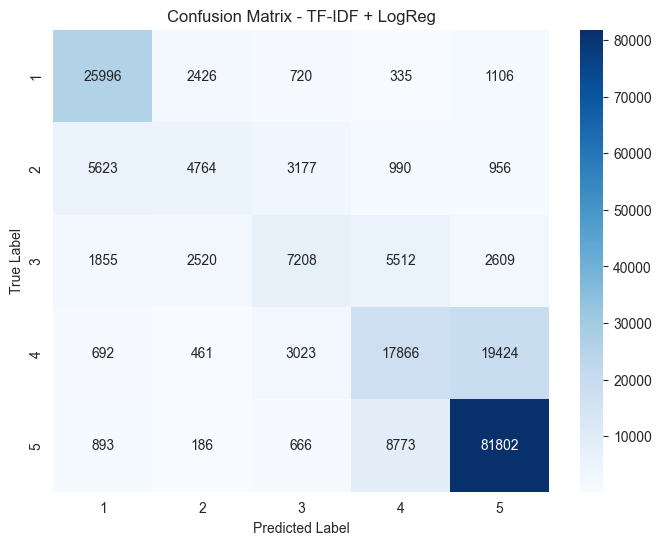

{'model': 'TF-IDF + LogReg',
 'type': 'ML Classique',
 'accuracy': 0.689617853223972,
 'f1_macro': 0.5760905139094874,
 'f1_weighted': 0.6721015183568818}

In [12]:
lr_tfidf = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)

lr_tfidf.fit(X_train_tfidf, y_train_rating)
evaluate_model(lr_tfidf, X_test_tfidf, y_test_rating, "TF-IDF + LogReg")

### 6.2 TF-IDF + SVM


 TF-IDF + SVM
Accuracy:     0.6822
F1-macro:     0.5393
F1-weighted:  0.6508

              precision    recall  f1-score   support

           1       0.71      0.88      0.79     30583
           2       0.48      0.21      0.29     15510
           3       0.51      0.27      0.35     19704
           4       0.52      0.39      0.45     41466
           5       0.75      0.91      0.82     92320

    accuracy                           0.68    199583
   macro avg       0.59      0.53      0.54    199583
weighted avg       0.65      0.68      0.65    199583



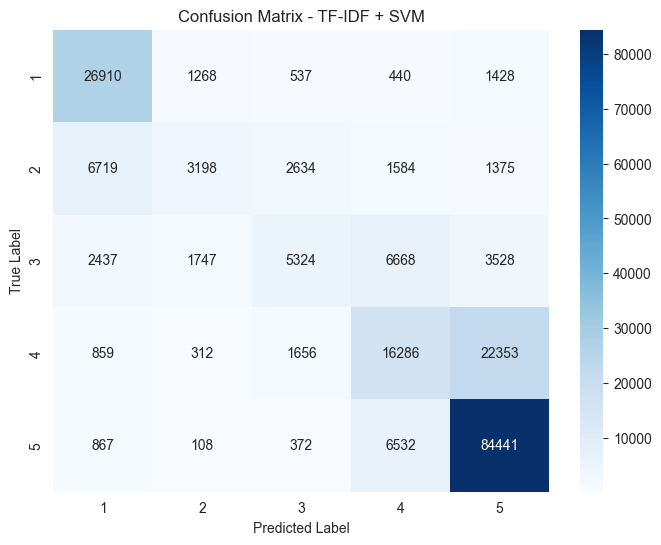

{'model': 'TF-IDF + SVM',
 'type': 'ML Classique',
 'accuracy': 0.6822174233276381,
 'f1_macro': 0.5393232275184227,
 'f1_weighted': 0.6508151470748773}

In [13]:
svm_tfidf = LinearSVC(
    max_iter=2000, 
    random_state=RANDOM_STATE
)

svm_tfidf.fit(X_train_tfidf, y_train_rating)
evaluate_model(svm_tfidf, X_test_tfidf, y_test_rating, "TF-IDF + SVM")

### 6.3 TF-IDF + Naive Bayes


 TF-IDF + NaiveBayes
Accuracy:     0.6363
F1-macro:     0.4718
F1-weighted:  0.5972

              precision    recall  f1-score   support

           1       0.66      0.78      0.72     30583
           2       0.40      0.15      0.22     15510
           3       0.44      0.16      0.24     19704
           4       0.46      0.35      0.40     41466
           5       0.70      0.90      0.79     92320

    accuracy                           0.64    199583
   macro avg       0.53      0.47      0.47    199583
weighted avg       0.60      0.64      0.60    199583



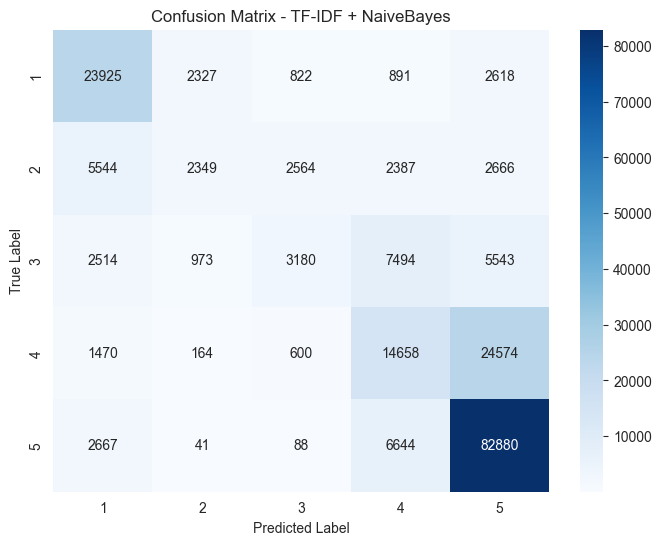

{'model': 'TF-IDF + NaiveBayes',
 'type': 'ML Classique',
 'accuracy': 0.6362866576812655,
 'f1_macro': 0.4717810408731172,
 'f1_weighted': 0.5972032264768471}

In [14]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train_rating)
evaluate_model(nb_tfidf, X_test_tfidf, y_test_rating, "TF-IDF + NaiveBayes")

### 6.4 TF-IDF + Random Forest


 TF-IDF + RandomForest
Accuracy:     0.5414
F1-macro:     0.2680
F1-weighted:  0.4186

              precision    recall  f1-score   support

           1       0.73      0.49      0.59     30583
           2       0.63      0.00      0.00     15510
           3       0.56      0.01      0.02     19704
           4       0.39      0.03      0.05     41466
           5       0.52      0.99      0.68     92320

    accuracy                           0.54    199583
   macro avg       0.57      0.30      0.27    199583
weighted avg       0.54      0.54      0.42    199583



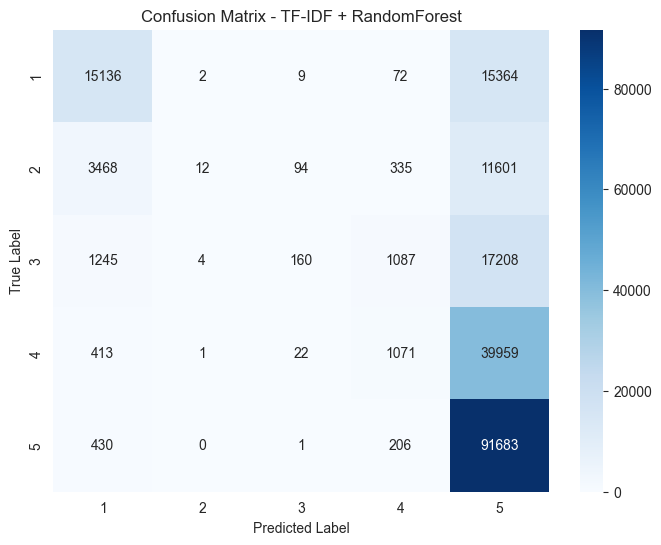

{'model': 'TF-IDF + RandomForest',
 'type': 'ML Classique',
 'accuracy': 0.5414389001067225,
 'f1_macro': 0.2680433389710766,
 'f1_weighted': 0.41855592418696974}

In [15]:
rf_tfidf = RandomForestClassifier(
    n_estimators=100, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    max_depth=20
)

rf_tfidf.fit(X_train_tfidf, y_train_rating)
evaluate_model(rf_tfidf, X_test_tfidf, y_test_rating, "TF-IDF + RandomForest")

## 7. Approche 3 : Embeddings Pré-entraînés (Sentence-BERT)

Utilisation de modèles de langage pré-entraînés pour obtenir des représentations denses et sémantiques.

In [16]:
# Embeddings SBERT précalculés (all-MiniLM-L6-v2, 384 dim)
X_train_embeddings = np.load(f'{FEATURES_DIR}/sbert_train.npy')
X_test_embeddings = np.load(f'{FEATURES_DIR}/sbert_test.npy')

print(f"Modèle utilisé : all-MiniLM-L6-v2")
print(f"Dimension des embeddings : {X_train_embeddings.shape[1]}")

Modèle utilisé : all-MiniLM-L6-v2
Dimension des embeddings : 384


In [17]:
# Les embeddings sont déjà chargés
print(f"Train embeddings shape: {X_train_embeddings.shape}")
print(f"Test embeddings shape: {X_test_embeddings.shape}")
print(f"Mémoire : ~{(X_train_embeddings.nbytes + X_test_embeddings.nbytes) / 1e6:.0f} Mo")

Train embeddings shape: (798328, 384)
Test embeddings shape: (199583, 384)
Mémoire : ~1533 Mo


### 7.1 Embeddings + Logistic Regression

Taille échantillon train: 159665 (20% de 798328)

 Embeddings + LogReg
Accuracy:     0.6440
F1-macro:     0.5075
F1-weighted:  0.6170

              precision    recall  f1-score   support

           1       0.69      0.82      0.75     30583
           2       0.39      0.22      0.28     15510
           3       0.40      0.27      0.32     19704
           4       0.46      0.34      0.39     41466
           5       0.73      0.88      0.79     92320

    accuracy                           0.64    199583
   macro avg       0.53      0.50      0.51    199583
weighted avg       0.61      0.64      0.62    199583



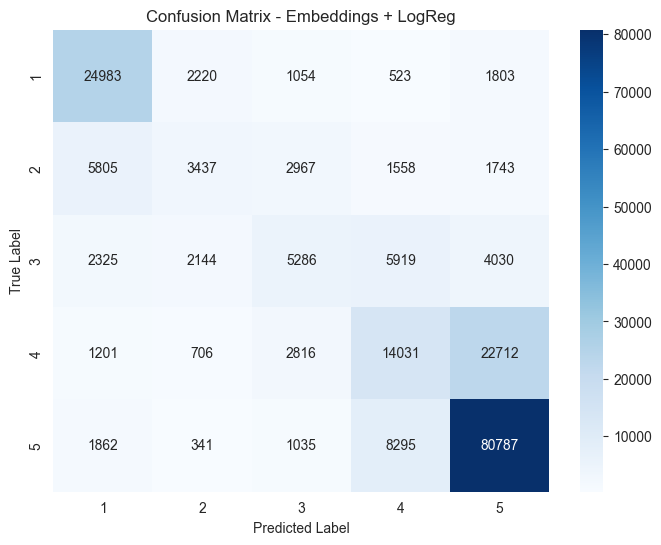

{'model': 'Embeddings + LogReg',
 'type': 'ML Classique',
 'accuracy': 0.643962662150584,
 'f1_macro': 0.507526790108151,
 'f1_weighted': 0.6170454610307242}

In [18]:
# Sous-échantillonnage à 20% pour éviter les problèmes de mémoire
from sklearn.model_selection import train_test_split

X_train_emb_sample, _, y_train_rating_sample, _ = train_test_split(
    X_train_embeddings, y_train_rating, 
    train_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y_train_rating
)

print(f"Taille échantillon train: {len(X_train_emb_sample)} (20% de {len(X_train_embeddings)})")

lr_emb = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)

lr_emb.fit(X_train_emb_sample, y_train_rating_sample)
evaluate_model(lr_emb, X_test_embeddings, y_test_rating, "Embeddings + LogReg")

### 7.2 Embeddings + SVM


 Embeddings + SVM
Accuracy:     0.6362
F1-macro:     0.4492
F1-weighted:  0.5838

              precision    recall  f1-score   support

           1       0.65      0.87      0.74     30583
           2       0.41      0.09      0.15     15510
           3       0.44      0.15      0.22     19704
           4       0.43      0.28      0.34     41466
           5       0.70      0.91      0.79     92320

    accuracy                           0.64    199583
   macro avg       0.53      0.46      0.45    199583
weighted avg       0.59      0.64      0.58    199583



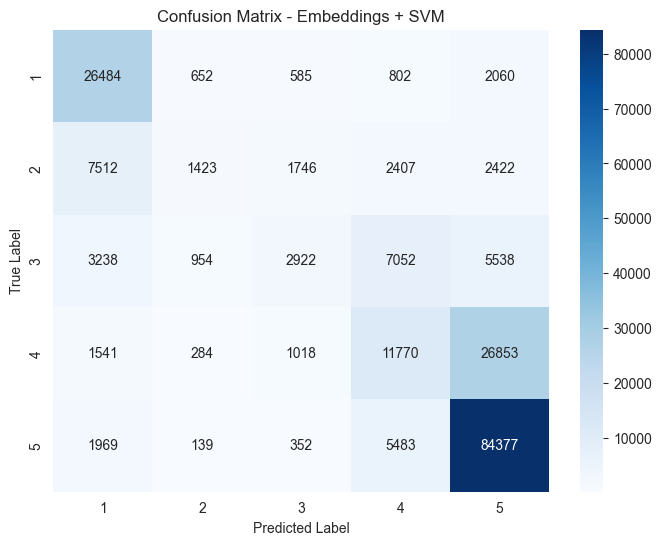

{'model': 'Embeddings + SVM',
 'type': 'ML Classique',
 'accuracy': 0.6362064905327608,
 'f1_macro': 0.449218241721722,
 'f1_weighted': 0.5837716625516758}

In [19]:
svm_emb = LinearSVC(
    max_iter=2000, 
    random_state=RANDOM_STATE
)

svm_emb.fit(X_train_emb_sample, y_train_rating_sample)
evaluate_model(svm_emb, X_test_embeddings, y_test_rating, "Embeddings + SVM")

### 7.3 Embeddings + Random Forest


 Embeddings + RandomForest
Accuracy:     0.5834
F1-macro:     0.3371
F1-weighted:  0.4860

              precision    recall  f1-score   support

           1       0.63      0.77      0.69     30583
           2       0.35      0.03      0.06     15510
           3       0.35      0.03      0.05     19704
           4       0.35      0.10      0.15     41466
           5       0.59      0.95      0.73     92320

    accuracy                           0.58    199583
   macro avg       0.45      0.38      0.34    199583
weighted avg       0.51      0.58      0.49    199583



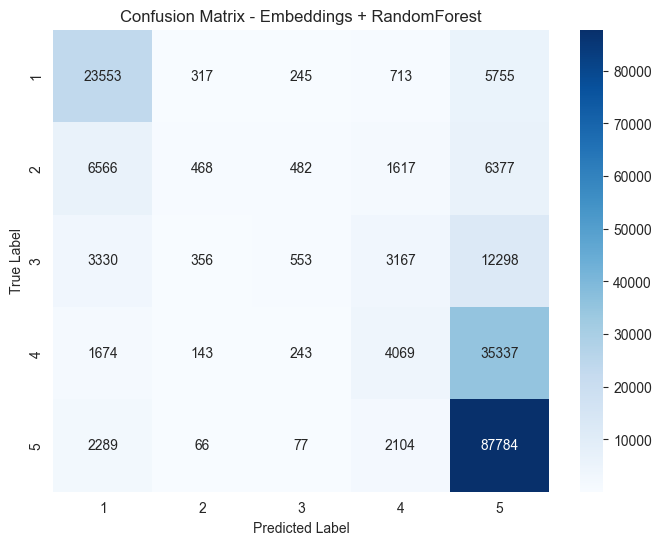

{'model': 'Embeddings + RandomForest',
 'type': 'ML Classique',
 'accuracy': 0.5833512874343005,
 'f1_macro': 0.3370596592427822,
 'f1_weighted': 0.485981463370282}

In [20]:
rf_emb = RandomForestClassifier(
    n_estimators=100, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    max_depth=20,
)

rf_emb.fit(X_train_embeddings, y_train_rating)
evaluate_model(rf_emb, X_test_embeddings, y_test_rating, "Embeddings + RandomForest")

## 8. Comparaison des Résultats

In [21]:
results_df = load_results()
results_df = results_df.sort_values('accuracy', ascending=False)

print("\n" + results_df.to_string(index=False))

best_model = results_df.iloc[0]
print(f"\n Meilleur modèle : {best_model['model']}")
print(f"   Accuracy: {best_model['accuracy']:.4f}")
print(f"   F1-macro: {best_model['f1_macro']:.4f}")


                    model          type  accuracy  f1_macro  f1_weighted
          TF-IDF + LogReg  ML Classique  0.689618  0.576091     0.672102
             TF-IDF + SVM  ML Classique  0.682217  0.539323     0.650815
             BOW + LogReg  ML Classique  0.680739  0.555751     0.655669
                BOW + SVM  ML Classique  0.667512  0.509644     0.625813
             MLP + TF-IDF Deep Learning  0.643998  0.584077     0.658502
      Embeddings + LogReg  ML Classique  0.643963  0.507527     0.617045
      TF-IDF + NaiveBayes  ML Classique  0.636287  0.471781     0.597203
         Embeddings + SVM  ML Classique  0.636206  0.449218     0.583772
         MLP + Embeddings Deep Learning  0.624136  0.561294     0.639032
         BOW + NaiveBayes  ML Classique  0.608048  0.518862     0.613683
Embeddings + RandomForest  ML Classique  0.583351  0.337060     0.485981
    TF-IDF + RandomForest  ML Classique  0.541439  0.268043     0.418556
       BOW + RandomForest  ML Classique  0.540783 

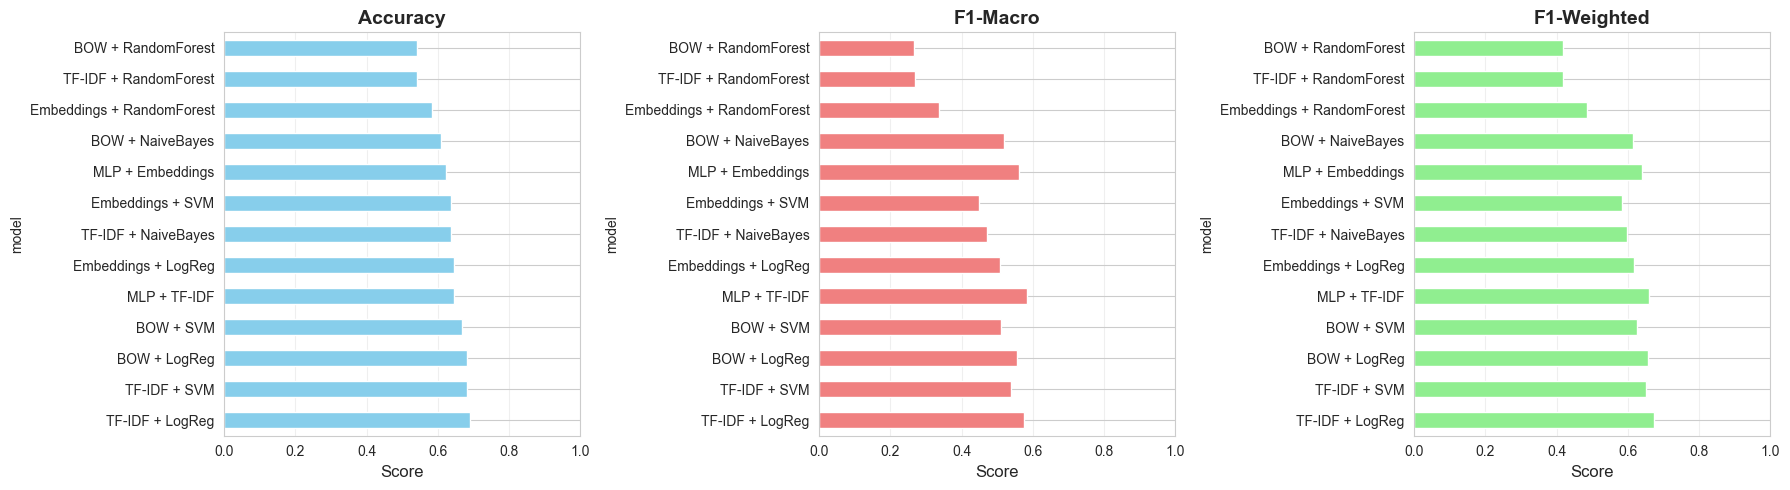


Graphique sauvegardé : ../results/ml_ratings_comparison.png


In [22]:
# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
results_df.plot(x='model', y='accuracy', kind='barh', ax=axes[0], legend=False, color='skyblue')
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_xlim([0, 1])
axes[0].grid(axis='x', alpha=0.3)

# F1-macro
results_df.plot(x='model', y='f1_macro', kind='barh', ax=axes[1], legend=False, color='lightcoral')
axes[1].set_title('F1-Macro', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_xlim([0, 1])
axes[1].grid(axis='x', alpha=0.3)

# F1-weighted
results_df.plot(x='model', y='f1_weighted', kind='barh', ax=axes[2], legend=False, color='lightgreen')
axes[2].set_title('F1-Weighted', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Score', fontsize=12)
axes[2].set_xlim([0, 1])
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/ml_ratings_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGraphique sauvegardé : ../results/ml_ratings_comparison.png")

## 9. Sauvegarde des Résultats et Modèles

In [ ]:
with open('../models/tfidf_svm.pkl', 'wb') as f:
    pickle.dump(svm_tfidf, f)

print("Modèle TF-IDF sauvegardé : ../models/tfidf_*")

# Embeddings model
with open('../models/embeddings_svm.pkl', 'wb') as f:
    pickle.dump(svm_emb, f)

print("Modèle Embeddings sauvegardé : ../models/embeddings_svm.pkl")

# Sauvegarder les méta-données
metadata = {
    'best_model': best_model['model'],
    'best_accuracy': float(best_model['accuracy']),
    'best_f1_macro': float(best_model['f1_macro']),
    'embedding_model': 'all-MiniLM-L6-v2',
    'train_size': len(X_train),
    'test_size': len(X_test),
    'random_state': RANDOM_STATE
}

with open('../results/ml_ratings_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Métadonnées sauvegardées : ../results/ml_ratings_metadata.json")

Modèle TF-IDF sauvegardé : ../models/tfidf_*
Modèle Embeddings sauvegardé : ../models/embeddings_svm.pkl
Métadonnées sauvegardées : ../results/ml_ratings_metadata.json
